# Memory: B and T

What changes when we double B or T?

| Config | B | T |
|---|---:|---:|
| baseline | 2 | 128 |
| b4 | 4 | 128 |
| t256 | 2 | 256 |

Same tiny GPT, MPS, FP32, naive attention. Three repeats of 1000 AdamW steps.

Results are in `results/repeat-*`. The notebook only reads them.
`tensor_MiB` counts live tensors; `driver_MiB` includes cache too. These are separate counters, not peaks.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

root = Path.cwd()
if root.name == "02_memory_scaling":
    root = root.parent.parent
results_dir = root / "experiments/02_memory_scaling/results"

configs = ["baseline", "b4", "t256"]
repeats = ["repeat-01", "repeat-02", "repeat-03"]
colors = {"baseline": "C0", "b4": "C1", "t256": "C2"}
styles = {"repeat-01": "-", "repeat-02": "--", "repeat-03": ":"}
metrics = ["tensor_MiB", "driver_MiB"]
stages = ["before_forward", "after_forward", "after_backward",
          "after_optimizer_step", "after_release"]
last_step = 1000

In [2]:
rows = []
for config in configs:
    for repeat in repeats:
        path = results_dir / repeat / f"{config}.json"
        with path.open() as file:
            result = json.load(file)
        for snapshot in result["snapshots"]:
            rows.append({
                "config": config, "repeat": repeat,
                "B": result["config"]["batch_size"],
                "T": result["config"]["sequence_length"],
                "step": snapshot["step"], "stage": snapshot["stage"],
                "tensor_MiB": snapshot["tensor_bytes"] / 2**20,
                "driver_MiB": snapshot["driver_bytes"] / 2**20,
            })

memory = pd.DataFrame(rows)

## First and last step

AdamW creates its states on the first update. Gradients are cleared before each forward.

In [3]:
first_last = memory[memory["step"].isin([1, last_step])]
first_last.pivot(index=["config", "repeat", "B", "T", "stage"],
                 columns="step", values=metrics).round(2)

tensor_MiB  ... driver_MiB
step                                                1     ...       1000
config   repeat    B T   stage                            ...           
b4       repeat-01 4 128 after_backward           153.79  ...     1160.8
                         after_forward            237.70  ...     1160.8
                         after_optimizer_step     207.06  ...     1160.8
                         after_release            107.06  ...     1160.8
                         before_forward            27.15  ...     1160.8
         repeat-02 4 128 after_backward           153.79  ...     1160.8
                         after_forward            237.70  ...     1160.8
                         after_optimizer_step     207.06  ...     1160.8
                         after_release            107.06  ...     1160.8
                         before_forward            27.15  ...     1160.8
         repeat-03 4 128 after_backward           153.79  ...     1160.8
                         after_forward            237.70  ...     1160.8
                         after_optimizer_step     207.06  ...     1160.8
                         after_release            107.06  ...     1160.8
                         before_forward            27.15  ...     1160.8
baseline repeat-01 2 128 after_backward           103.78  ...     1100.8
                         after_forward            132.44  ...     1100.8
                         after_optimizer_step     157.06  ...     1100.8
                         after_release            107.06  ...     1100.8
                         before_forward            27.14  ...     1100.8
         repeat-02 2 128 after_backward           103.78  ...     1100.8
                         after_forward            132.44  ...     1100.8
                         after_optimizer_step     157.06  ...     1100.8
                         after_release            107.06  ...     1100.8
                         before_forward            27.14  ...     1100.8
         repeat-03 2 128 after_backward           103.78  ...     1100.8
                         after_forward            132.44  ...     1100.8
                         after_optimizer_step     157.06  ...     1100.8
                         after_release            107.06  ...     1100.8
                         before_forward            27.14  ...     1100.8
t256     repeat-01 2 256 after_backward           153.79  ...     1160.8
                         after_forward            239.79  ...     1160.8
                         after_optimizer_step     207.06  ...     1160.8
                         after_release            107.06  ...     1160.8
                         before_forward            27.15  ...     1160.8
         repeat-02 2 256 after_backward           153.79  ...     1160.8
                         after_forward            239.79  ...     1160.8
                         after_optimizer_step     207.06  ...     1160.8
                         after_release            107.06  ...     1160.8
                         before_forward            27.15  ...     1160.8
         repeat-03 2 256 after_backward           153.79  ...     1160.8
                         after_forward            239.79  ...     1160.8
                         after_optimizer_step     207.06  ...     1160.8
                         after_release            107.06  ...     1160.8
                         before_forward            27.15  ...     1160.8

[45 rows x 4 columns]

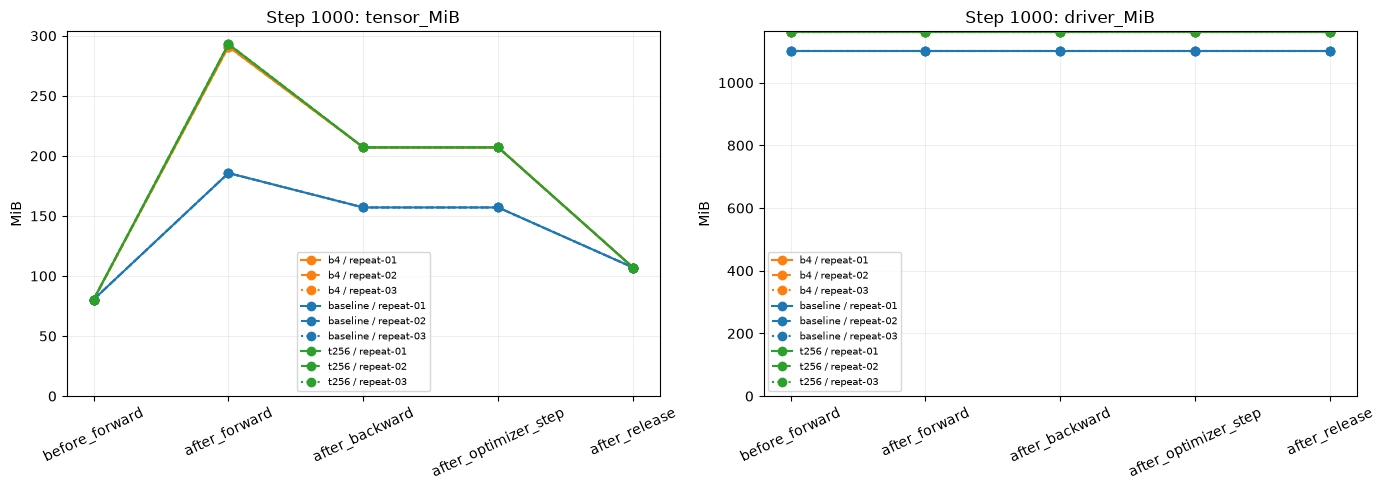

In [4]:
last = memory[memory["step"] == last_step]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, metrics):
    for (config, repeat), points in last.groupby(["config", "repeat"]):
        points = points.set_index("stage").loc[stages]
        ax.plot(stages, points[metric], marker="o", color=colors[config],
                linestyle=styles[repeat], label=f"{config} / {repeat}")
    ax.set_title(f"Step {last_step}: {metric}")
    ax.set_ylabel("MiB")
    ax.set_ylim(bottom=0)
    ax.tick_params(axis="x", labelrotation=25)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

## After forward

The repeats overlap: they gave the same readings.

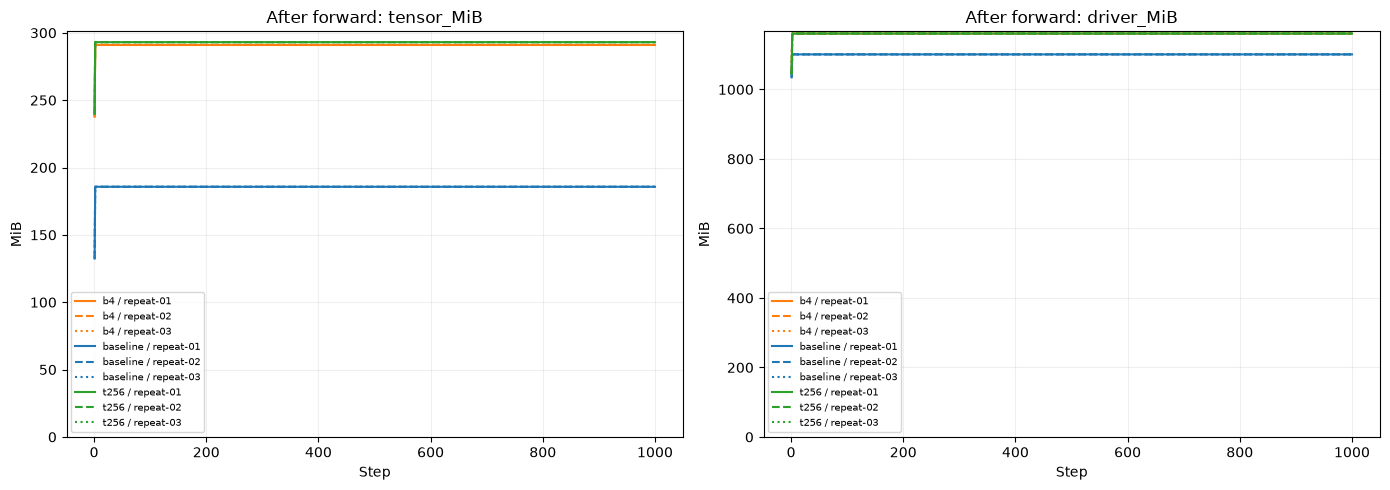

In [5]:
forward = memory[memory["stage"] == "after_forward"]
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, metric in zip(axes, metrics):
    for (config, repeat), points in forward.groupby(["config", "repeat"]):
        points = points.sort_values("step")
        ax.plot(points["step"], points[metric], color=colors[config],
                linestyle=styles[repeat], label=f"{config} / {repeat}")
    ax.set_title(f"After forward: {metric}")
    ax.set_xlabel("Step")
    ax.set_ylabel("MiB")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()